In [ ]:
# RT-DETR Solder Defect Notebook



This notebook documents the current RT-DETR solder-defect workflow in this workspace.



It covers:



- dataset inspection for the YOLO labels used to train RT-DETR

- class-distribution and bounding-box plots

- sample annotation previews from the validation split

- a live inference check using the current deployed RT-DETR weights



The current supported classes are:



- `good` -> `Good Solder`

- `exc_solder` -> `Excess Solder`

- `poor_solder` -> `Insufficient Solder`

- `spike` -> `Solder Spike`


In [1]:
from __future__ import annotations



import base64

from collections import Counter, defaultdict

from io import BytesIO

from pathlib import Path

import random



import matplotlib.pyplot as plt

import matplotlib.patches as patches

import numpy as np

from PIL import Image



from rtdetr.inference import predict_image_bytes, default_weights_path



PROJECT_ROOT = Path.cwd()

DATASET_ROOT = PROJECT_ROOT / "YOLO" / "dataset2"

IMAGE_DIRS = {

    "train": DATASET_ROOT / "images" / "train",

    "val": DATASET_ROOT / "images" / "val",

}

LABEL_DIRS = {

    "train": DATASET_ROOT / "labels" / "train",

    "val": DATASET_ROOT / "labels" / "val",

}

CLASS_NAMES = {

    0: "good",

    1: "exc_solder",

    2: "poor_solder",

    3: "spike",

}

DISPLAY_NAMES = {

    "good": "Good Solder",

    "exc_solder": "Excess Solder",

    "poor_solder": "Insufficient Solder",

    "spike": "Solder Spike",

}

CLASS_COLORS = {

    "good": "#41b879",

    "exc_solder": "#ff8f33",

    "poor_solder": "#ff5f4d",

    "spike": "#ffcb3c",

}



print(f"Project root: {PROJECT_ROOT}")

print(f"Dataset root: {DATASET_ROOT}")

print(f"Weights: {default_weights_path()}")


Project root: c:\Users\Mong\Desktop\Eden\RT-DETR
Dataset root: c:\Users\Mong\Desktop\Eden\RT-DETR\YOLO\dataset2
Weights: C:\Users\Mong\Desktop\Eden\RT-DETR\rtdetr\runs\solder_defects_rtdetr\weights\best.pt


In [2]:
def parse_label_file(label_path: Path, split: str) -> list[dict]:

    image_path = IMAGE_DIRS[split] / f"{label_path.stem}.jpg"

    if not image_path.exists():

        image_path = IMAGE_DIRS[split] / f"{label_path.stem}.png"

    if not image_path.exists():

        return []



    with Image.open(image_path) as image:

        image_width, image_height = image.size



    records: list[dict] = []

    for raw_line in label_path.read_text(encoding="utf-8").splitlines():

        if not raw_line.strip():

            continue

        class_id, cx, cy, w, h = raw_line.split()

        class_name = CLASS_NAMES[int(class_id)]

        center_x = float(cx) * image_width

        center_y = float(cy) * image_height

        box_width = float(w) * image_width

        box_height = float(h) * image_height

        x1 = center_x - (box_width / 2)

        y1 = center_y - (box_height / 2)

        x2 = center_x + (box_width / 2)

        y2 = center_y + (box_height / 2)

        records.append(

            {

                "split": split,

                "image_path": image_path,

                "label_path": label_path,

                "class_name": class_name,

                "display_name": DISPLAY_NAMES[class_name],

                "image_width": image_width,

                "image_height": image_height,

                "center_x": center_x,

                "center_y": center_y,

                "box_width": box_width,

                "box_height": box_height,

                "x1": x1,

                "y1": y1,

                "x2": x2,

                "y2": y2,

                "area_ratio": (box_width * box_height) / max(1, image_width * image_height),

            }

        )

    return records





all_records: list[dict] = []

records_by_image: dict[str, list[dict]] = defaultdict(list)

split_image_counts: dict[str, int] = {}



for split, label_dir in LABEL_DIRS.items():

    split_image_counts[split] = len(list(label_dir.glob("*.txt")))

    for label_path in sorted(label_dir.glob("*.txt")):

        items = parse_label_file(label_path, split)

        all_records.extend(items)

        if items:

            records_by_image[str(items[0]["image_path"])] = items



print(f"Loaded {len(all_records)} labeled objects across {sum(split_image_counts.values())} labeled images.")

print(f"Train images: {split_image_counts['train']}")

print(f"Val images: {split_image_counts['val']}")

print(f"Classes present: {sorted({item['class_name'] for item in all_records})}")


Loaded 948 labeled objects across 529 labeled images.
Train images: 312
Val images: 217
Classes present: ['exc_solder', 'good', 'poor_solder', 'spike']



TRAIN class counts
  Good Solder            186
  Excess Solder          182
  Insufficient Solder    57
  Solder Spike           130

VAL class counts
  Good Solder            125
  Excess Solder          133
  Insufficient Solder    34
  Solder Spike           101


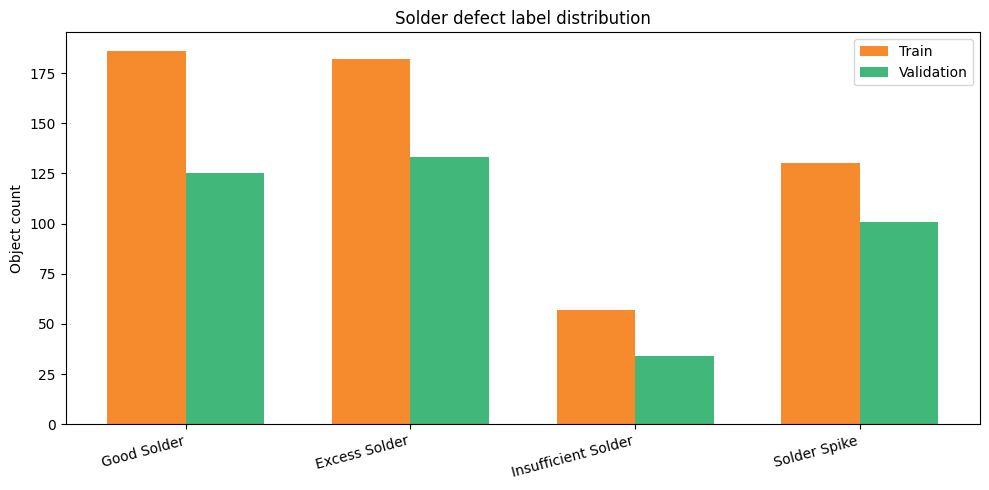

In [3]:
split_class_counts: dict[str, Counter] = {split: Counter() for split in LABEL_DIRS}

for item in all_records:

    split_class_counts[item["split"]][item["class_name"]] += 1



for split, counter in split_class_counts.items():

    print(f"\n{split.upper()} class counts")

    for class_name in CLASS_NAMES.values():

        print(f"  {DISPLAY_NAMES[class_name]:<22} {counter[class_name]}")



class_order = list(CLASS_NAMES.values())

x = np.arange(len(class_order))

bar_width = 0.35



fig, ax = plt.subplots(figsize=(10, 5))

train_values = [split_class_counts["train"][class_name] for class_name in class_order]

val_values = [split_class_counts["val"][class_name] for class_name in class_order]

ax.bar(x - bar_width / 2, train_values, width=bar_width, label="Train", color="#f68b2d")

ax.bar(x + bar_width / 2, val_values, width=bar_width, label="Validation", color="#41b879")

ax.set_xticks(x)

ax.set_xticklabels([DISPLAY_NAMES[class_name] for class_name in class_order], rotation=15, ha="right")

ax.set_ylabel("Object count")

ax.set_title("Solder defect label distribution")

ax.legend()

plt.tight_layout()

plt.show()


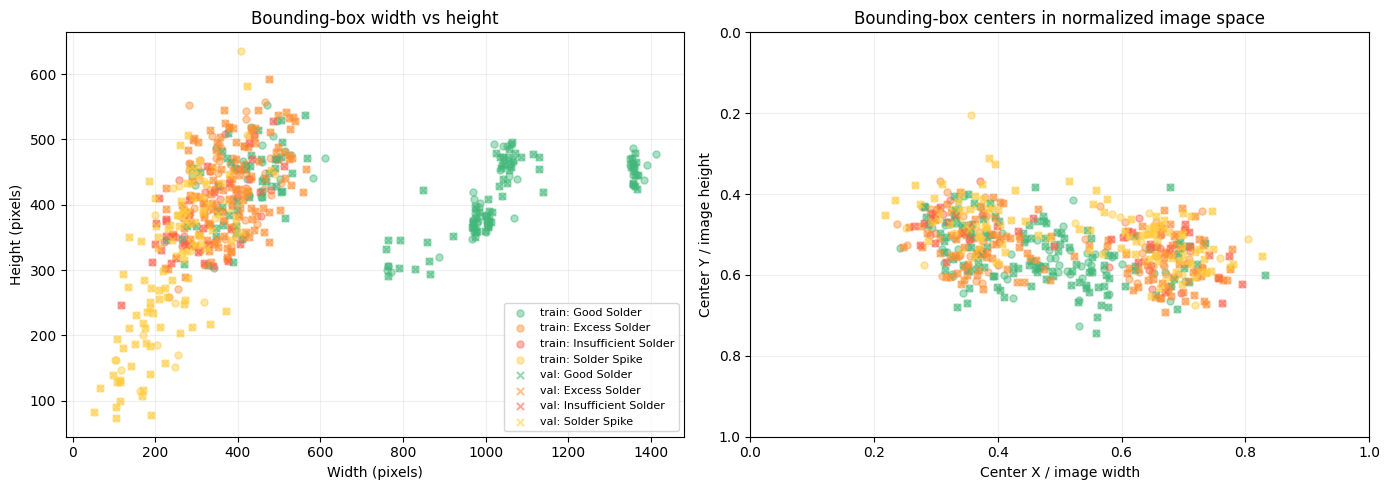

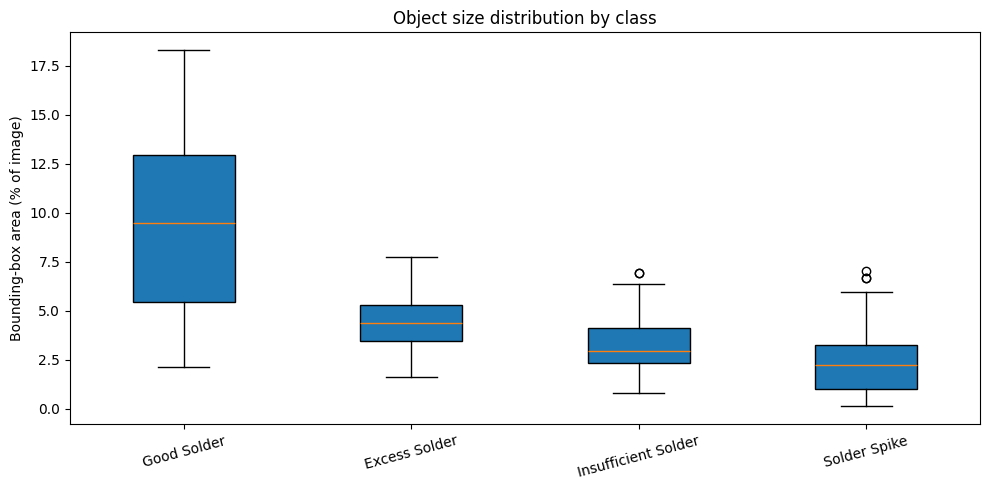

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))



for split, marker, alpha in [("train", "o", 0.45), ("val", "x", 0.55)]:

    split_records = [item for item in all_records if item["split"] == split]

    for class_name in CLASS_NAMES.values():

        class_records = [item for item in split_records if item["class_name"] == class_name]

        if not class_records:

            continue

        axes[0].scatter(

            [item["box_width"] for item in class_records],

            [item["box_height"] for item in class_records],

            s=26,

            alpha=alpha,

            marker=marker,

            color=CLASS_COLORS[class_name],

            label=f"{split}: {DISPLAY_NAMES[class_name]}",

        )

        axes[1].scatter(

            [item["center_x"] / item["image_width"] for item in class_records],

            [item["center_y"] / item["image_height"] for item in class_records],

            s=26,

            alpha=alpha,

            marker=marker,

            color=CLASS_COLORS[class_name],

        )



axes[0].set_title("Bounding-box width vs height")

axes[0].set_xlabel("Width (pixels)")

axes[0].set_ylabel("Height (pixels)")

axes[0].grid(alpha=0.2)



axes[1].set_title("Bounding-box centers in normalized image space")

axes[1].set_xlabel("Center X / image width")

axes[1].set_ylabel("Center Y / image height")

axes[1].set_xlim(0, 1)

axes[1].set_ylim(1, 0)

axes[1].grid(alpha=0.2)



handles, labels = axes[0].get_legend_handles_labels()

unique = dict(zip(labels, handles))

axes[0].legend(unique.values(), unique.keys(), fontsize=8, loc="best")

plt.tight_layout()

plt.show()



area_by_class = defaultdict(list)

for item in all_records:

    area_by_class[item["class_name"]].append(item["area_ratio"] * 100)



fig, ax = plt.subplots(figsize=(10, 5))

box_data = [area_by_class[class_name] for class_name in CLASS_NAMES.values()]

ax.boxplot(box_data, tick_labels=[DISPLAY_NAMES[class_name] for class_name in CLASS_NAMES.values()], patch_artist=True)

for patch, class_name in zip(ax.artists, CLASS_NAMES.values()):

    patch.set_facecolor(CLASS_COLORS[class_name])

ax.set_ylabel("Bounding-box area (% of image)")

ax.set_title("Object size distribution by class")

ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.show()


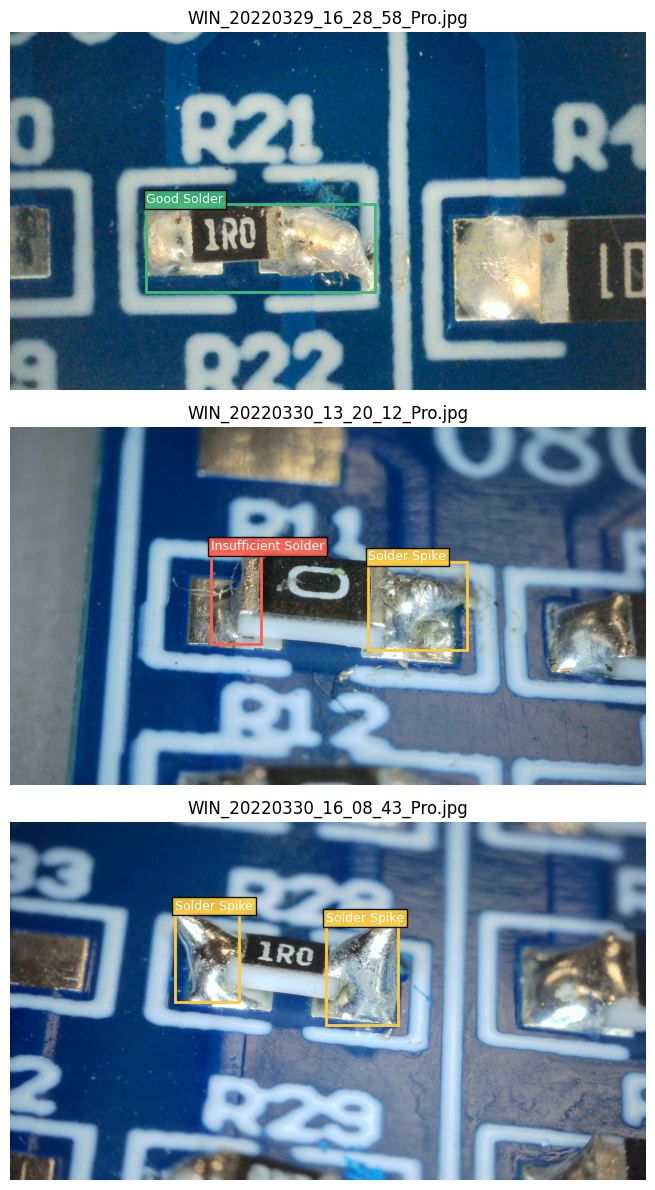

In [5]:
def show_annotated_examples(split: str = "val", seed: int = 7, limit: int = 4) -> None:

    image_paths = sorted({Path(key) for key, items in records_by_image.items() if items and items[0]["split"] == split})

    random.Random(seed).shuffle(image_paths)

    chosen = image_paths[:limit]



    fig, axes = plt.subplots(len(chosen), 1, figsize=(14, 4 * len(chosen)))

    if len(chosen) == 1:

        axes = [axes]



    for ax, image_path in zip(axes, chosen):

        image = Image.open(image_path).convert("RGB")

        ax.imshow(image)

        for item in records_by_image[str(image_path)]:

            rect = patches.Rectangle(

                (item["x1"], item["y1"]),

                item["box_width"],

                item["box_height"],

                linewidth=2,

                edgecolor=CLASS_COLORS[item["class_name"]],

                facecolor="none",

            )

            ax.add_patch(rect)

            ax.text(

                item["x1"],

                max(12, item["y1"] - 6),

                item["display_name"],

                fontsize=9,

                color="#ffffff",

                bbox={"facecolor": CLASS_COLORS[item["class_name"]], "alpha": 0.9, "pad": 2},

            )

        ax.set_title(image_path.name)

        ax.axis("off")



    plt.tight_layout()

    plt.show()





show_annotated_examples(split="val", seed=11, limit=3)


Image: WIN_20220330_13_11_29_Pro.jpg
Overall: defect
Board region used: False
Total detections: 4
- Solder Spike: 0.792 | [1502.88, 605.8, 1638.72, 775.17]
- Solder Spike: 0.784 | [110.08, 458.06, 372.68, 803.49]
- Insufficient Solder: 0.651 | [1446.1, 556.06, 1786.82, 903.2]
- Solder Spike: 0.620 | [743.93, 541.68, 1009.39, 846.85]


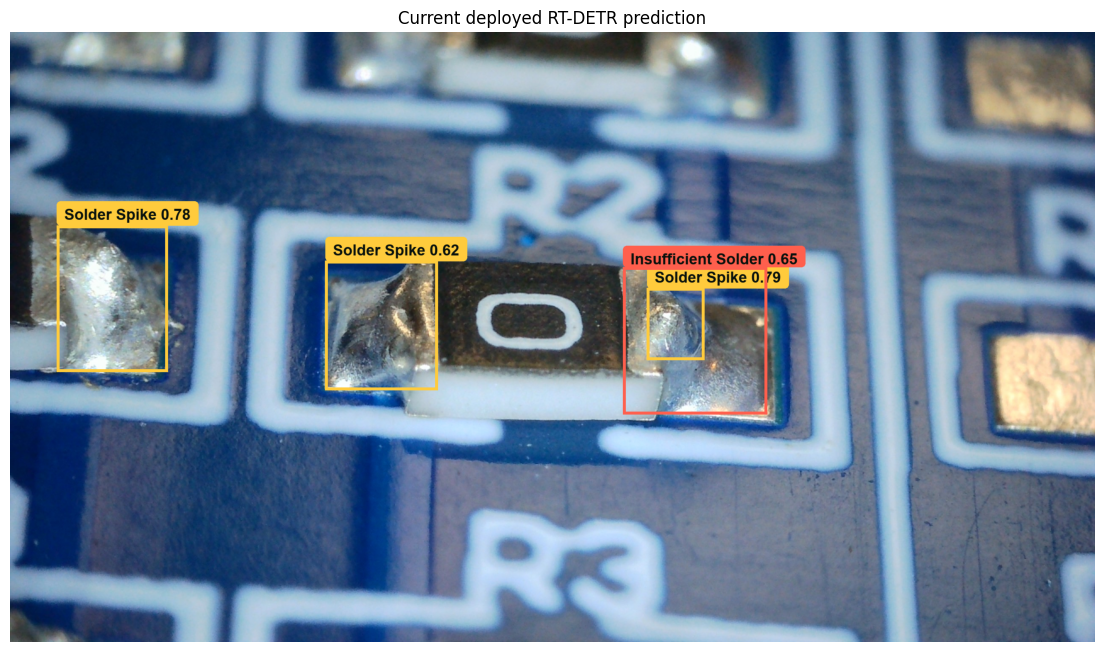

In [6]:
sample_image = DATASET_ROOT / "images" / "val" / "WIN_20220330_13_11_29_Pro.jpg"

sample_bytes = sample_image.read_bytes()

prediction = predict_image_bytes(sample_bytes, imgsz=640, conf=0.12, iou=0.7)



print("Image:", sample_image.name)

print("Overall:", prediction["overall"])

print("Board region used:", bool(prediction["board_region"]))

print("Total detections:", prediction["total_detections"])

for item in prediction["detections"]:

    print(f"- {item['label']}: {item['confidence']:.3f} | {item['bbox']}")



annotated_image = Image.open(BytesIO(base64.b64decode(prediction["annotated_image_base64"])))

plt.figure(figsize=(14, 8))

plt.imshow(annotated_image)

plt.title("Current deployed RT-DETR prediction")

plt.axis("off")

plt.show()


## Notes



- The deployed browser app now uses the same inference code that this notebook calls through `predict_image_bytes(...)`.

- Full-frame inference is always used as the baseline.

- Board-guided inference is only added when the detected board area is large enough to be credible.

- This avoids the earlier failure mode where macro close-up images were mis-cropped into a small false board region and misclassified.



If you retrain the model later, rerun this notebook to refresh the dataset plots and inference preview against the new weights.
